# 🧬 RNA-seq Pipeline — rd1 vs WT (Mouse Retina) — Google Colab

Complete transcriptomics pipeline from raw FASTQ to pathway enrichment and network analysis.

**Dataset:** GSE183117 — Mouse retina (P10), rd1 mutation vs wild-type  
**Organism:** *Mus musculus* (GRCm39 / Ensembl 110)  
**Contrast:** rd1 vs WT  

---

## 📚 Pipeline overview

```
SRA Downloads (FASTQ)
    │
    ├── [Step 0]  Environment setup (condacolab + mamba + R packages)
    ├── [Step 1]  Download FASTQ files (sra-tools)
    ├── [Step 2]  Quality control — FastQC + MultiQC
    ├── [Step 3]  Trimming — fastp (adapters + Q20, faster than Trimmomatic)
    ├── [Step 4]  Alignment — HISAT2 (splice-aware, low memory)
    ├── [Step 5]  Quantification — featureCounts (raw integer counts)
    ├── [Step 6]  DESeq2 — QC: PCA + correlation heatmap (all samples)
    ├── [Step 7]  Outlier removal + repeat QC
    ├── [Step 8]  Differential expression (DESeq2, BH correction)
    ├── [Step 9]  ENSEMBL → gene symbols + Entrez IDs (org.Mm.eg.db)
    ├── [Step 10] Visualization — plotMA, EnhancedVolcano, DEG heatmap
    ├── [Step 11] Enrichment — GSEA (dotplot + table each)
    └── [Step 12] Network analysis — STRINGdb + igraph
```

**Tool choices:**
- **fastp** over Trimmomatic: 2–4× faster, built-in QC report, auto adapter detection
- **HISAT2** over STAR: ~4× less memory (8 GB vs 30 GB index), equally accurate for known splicing
- **featureCounts** over HTSeq: 10–20× faster, multi-threaded, single command for all samples
- **DESeq2**: raw integer counts required — never use pre-normalized values as input

> ⚠️ Run **Step 0.1** first, wait for the kernel to restart, then continue from **Step 0.2**.

## Step 0 — Environment setup

In [1]:
# ── 0.1 Install condacolab (kernel will restart automatically) ────────────────
!pip install --upgrade --force-reinstall zstandard --quiet
!pip install -q condacolab
import condacolab
condacolab.install()
# Wait for kernel restart before running Step 0.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 42.6 MB/s eta 0:00:00
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [1]:
# ── 0.2 Remove version pins that cause conflicts ──────────────────────────────
!sed -i '/cudatoolkit/d' /usr/local/conda-meta/pinned
!sed -i '/python/d' /usr/local/conda-meta/pinned
!mamba install -c conda-forge curl -y --quiet
!echo "mamba ready"
!mamba env list

Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done
mamba ready

# conda environments:
#
base                   /usr/local



In [2]:
# ── 0.3 Install bioinformatics tools ─────────────────────────────────────────
!mamba create -n sra      -c bioconda sra-tools          -y --quiet
!mamba create -n qc       -c bioconda fastqc multiqc fastp -y --quiet
!mamba create -n hisat2   -c bioconda hisat2 samtools subread -y --quiet

!echo "All conda environments created:"
!mamba env list

Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done
Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done
Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done
All conda environments created:

# conda environments:
#
base                   /usr/local
hisat2                 /usr/local/envs/hisat2
qc                     /usr/local/envs/qc
sra                    /usr/local/envs/sra



In [3]:
# ── 0.5 Create output folder structure ───────────────────────────────────────
import os
folders = [
    "data/fastq", "data/trimmed", "data/bam", "data/counts",
    "ref/genome", "ref/annotation", "ref/hisat2_index",
    "figures/qc", "figures/deseq2", "figures/enrichment", "figures/network",
    "tables"
]
for d in folders:
    os.makedirs(d, exist_ok=True)

## Step 1 — Download FASTQ files (SRA)

| SRR | Condition | Replicate |
|-----|-----------|-----------|
| SRR15679348 | WT | 1 |
| SRR15679349 | WT | 2 |
| SRR15679350 | WT | 3 |
| SRR15679351 | WT | 4 |
| SRR15679346 | rd1 | 1 |
| SRR15679347 | rd1 | 2 |

`prefetch` downloads the SRA cache; `fasterq-dump` converts to paired FASTQ.
> GEO accession: GSE183117
> Citation: Jiang K, Mondal AK et al. Multiomics analyses reveal early metabolic imbalance and mitochondrial stress in neonatal photoreceptors leading to cell death in Pde6brd1/rd1 mouse model of retinal degeneration. Hum Mol Genet 2022 Jul 7;31(13):2137-2154. PMID: 35075486

In [4]:
%%bash
SAMPLES="SRR15679347 SRR15679346 SRR15679349 SRR15679348"

for SRR in $SAMPLES; do
  echo "=== Downloading $SRR ==="
  mamba run -n sra prefetch $SRR
  mamba run -n sra fasterq-dump --split-files --threads 4 $SRR -O data/fastq/
  gzip data/fastq/${SRR}_*.fastq
done

ls -lh data/fastq/*.fastq.gz

=== Downloading SRR15679347 ===
2026-06-25T21:06:00 prefetch.3.4.1: 1) Resolving 'SRR15679347'...
2026-06-25T21:06:01 prefetch.3.4.1: Current preference is set to retrieve SRA Normalized Format files with full base quality scores
2026-06-25T21:06:01 prefetch.3.4.1: 1) Downloading 'SRR15679347'...
2026-06-25T21:06:01 prefetch.3.4.1:  SRA Normalized Format file is being retrieved
2026-06-25T21:06:01 prefetch.3.4.1:  Downloading via HTTPS...
2026-06-25T21:07:09 prefetch.3.4.1:  HTTPS download succeed
2026-06-25T21:07:13 prefetch.3.4.1:  'SRR15679347' is valid: 1781501468 bytes were streamed from 1781495501
2026-06-25T21:07:13 prefetch.3.4.1: 1) 'SRR15679347' was downloaded successfully
2026-06-25T21:07:13 prefetch.3.4.1: 1) Resolving 'SRR15679347's dependencies...
2026-06-25T21:07:14 prefetch.3.4.1: 'SRR15679347' has 0 unresolved dependencies

=== Downloading SRR15679346 ===
2026-06-25T21:44:15 prefetch.3.4.1: 1) Resolving 'SRR15679346'...
2026-06-25T21:44:16 prefetch.3.4.1: Current prefe

spots read      : 21,232,424
reads read      : 42,464,848
reads written   : 42,464,848

spots read      : 27,477,850
reads read      : 54,955,700
reads written   : 54,955,700

spots read      : 16,518,241
reads read      : 33,036,482
reads written   : 33,036,482

spots read      : 17,124,928
reads read      : 34,249,856
reads written   : 34,249,856



## Step 2 — Quality control (FastQC + MultiQC)

In [5]:
%%bash
echo "=== FastQC — pre-trimming ==="
mamba run -n qc fastqc data/fastq/*.fastq.gz -o figures/qc/ -t 5 --quiet

echo "=== MultiQC — pre-trimming ==="
mamba run -n qc multiqc figures/qc/ -o figures/qc/ -n multiqc_pretrim --quiet

=== FastQC — pre-trimming ===
[0.017s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.018s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip

=== MultiQC — pre-trimming ===


In [ ]:
# Download MultiQC pre-trim report
from google.colab import files
files.download("figures/qc/multiqc_pretrim.html")

## Step 3 — Trimming (fastp)

**Parameters applied:**
- `--detect_adapter_for_pe`: auto-detect adapters in paired-end mode
- `--qualified_quality_phred 25`: trim bases with Q < 25
- `--length_required 40`: discard reads shorter than 40 bp
- `--thread 4`: parallel processing

In [7]:
%%bash
SAMPLES="SRR15679348 SRR15679349 SRR15679350 SRR15679351 SRR15679346 SRR15679347"

for SRR in $SAMPLES; do
  echo "=== Trimming $SRR ==="
  mamba run -n qc fastp \
    -i data/fastq/${SRR}_1.fastq.gz \
    -I data/fastq/${SRR}_2.fastq.gz \
    -o data/trimmed/${SRR}_R1_trim.fastq.gz \
    -O data/trimmed/${SRR}_R2_trim.fastq.gz \
    --detect_adapter_for_pe \
    --qualified_quality_phred 25 \
    --length_required 40 \
    --thread 4 \
    --json figures/qc/${SRR}_fastp.json \
    --html figures/qc/${SRR}_fastp.html \
    --disable_length_filtering false
  echo "Done: $SRR"
done

echo "Trimmed files:"
ls -lh data/trimmed/*.fastq.gz

=== Trimming SRR15679348 ===
Done: SRR15679348
=== Trimming SRR15679349 ===
Done: SRR15679349
=== Trimming SRR15679350 ===
Done: SRR15679350
=== Trimming SRR15679351 ===
Done: SRR15679351
=== Trimming SRR15679346 ===
Done: SRR15679346
=== Trimming SRR15679347 ===
Done: SRR15679347
Trimmed files:
-rw-r--r-- 1 root root  1.7G Jun 26 00:38 data/trimmed/SRR15679346_R1_trim.fastq.gz
-rw-r--r-- 1 root root  1.7G Jun 26 00:38 data/trimmed/SRR15679346_R2_trim.fastq.gz
-rw-r--r-- 1 root root  1.3G Jun 26 00:50 data/trimmed/SRR15679347_R1_trim.fastq.gz
-rw-r--r-- 1 root root  1.3G Jun 26 00:50 data/trimmed/SRR15679347_R2_trim.fastq.gz
-rw-r--r-- 1 root root  998M Jun 26 00:14 data/trimmed/SRR15679348_R1_trim.fastq.gz
-rw-r--r-- 1 root root 1004M Jun 26 00:14 data/trimmed/SRR15679348_R2_trim.fastq.gz
-rw-r--r-- 1 root root  957M Jun 26 00:22 data/trimmed/SRR15679349_R1_trim.fastq.gz
-rw-r--r-- 1 root root  970M Jun 26 00:22 data/trimmed/SRR15679349_R2_trim.fastq.gz


Detecting adapter sequence for read1...
>Illumina TruSeq Adapter Read 1
AGATCGGAAGAGCACACGTCTGAACTCCAGTCA

Detecting adapter sequence for read2...
>Illumina TruSeq Adapter Read 2
AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT

Read1 before filtering:
total reads: 17124928
total bases: 2157740928
Q20 bases: 2124932119(98.4795%)
Q30 bases: 2089739716(96.8485%)
Q40 bases: 0(0%)

Read2 before filtering:
total reads: 17124928
total bases: 2157740928
Q20 bases: 2104856034(97.5491%)
Q30 bases: 2059384032(95.4417%)
Q40 bases: 0(0%)

Read1 after filtering:
total reads: 16751280
total bases: 2004200729
Q20 bases: 1981386549(98.8617%)
Q30 bases: 1953180589(97.4543%)
Q40 bases: 0(0%)

Read2 after filtering:
total reads: 16751280
total bases: 2004198557
Q20 bases: 1973806375(98.4836%)
Q30 bases: 1940259947(96.8098%)
Q40 bases: 0(0%)

Filtering result:
reads passed filter: 33502560
reads failed due to low quality: 679290
reads failed due to too many N: 11700
reads failed due to adapter dimer: 55736
reads with ad

In [8]:
%%bash
# Post-trimming QC
echo "=== FastQC — post-trimming ==="
mamba run -n qc fastqc data/trimmed/*.fastq.gz -o figures/qc/ -t 2 --quiet

echo "=== MultiQC — post-trimming (includes fastp JSON reports) ==="
mamba run -n qc multiqc figures/qc/ -o figures/qc/ -n multiqc_posttrim --quiet

echo "Post-trim QC saved:"
ls figures/qc/multiqc_posttrim.html

=== FastQC — post-trimming ===
[0.010s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.010s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip
application/gzip

=== MultiQC — post-trimming (includes fastp JSON reports) ===
Post-trim QC saved:
figures/qc/multiqc_posttrim.html


In [ ]:
from google.colab import files
files.download("figures/qc/multiqc_posttrim.html")

## Step 4 — Alignment (HISAT2)

**Why HISAT2 over STAR?**

| Feature | HISAT2 | STAR |
|---------|--------|------|
| Index memory | ~8 GB (GRCm39) | ~30 GB (GRCm39) |
| Alignment speed | Fast | Faster |
| Splice-aware | ✅ Yes | ✅ Yes |
| Novel junction detection | ✅ Good | ✅ Excellent |
| Colab free tier (12 GB RAM) | ✅ Fits comfortably | ⚠️ Tight |
| Standard in publications | ✅ Widely used | ✅ Widely used |

For known-transcriptome quantification (which we do with featureCounts + GTF), HISAT2 and STAR give equivalent results.

In [9]:
%%bash
# Download GRCm39 reference genome and GTF annotation (Ensembl 110)
echo "=== Downloading reference genome (GRCm39, chr1–19 + X + Y + MT) ==="
wget -q "https://ftp.ensembl.org/pub/release-110/fasta/mus_musculus/dna/Mus_musculus.GRCm39.dna.toplevel.fa.gz" \
  -O ref/genome/GRCm39.fa.gz
gunzip ref/genome/GRCm39.fa.gz

echo "=== Downloading GTF annotation (Ensembl 110) ==="
wget -q "https://ftp.ensembl.org/pub/release-110/gtf/mus_musculus/Mus_musculus.GRCm39.110.gtf.gz" \
  -O ref/annotation/GRCm39.110.gtf.gz
gunzip ref/annotation/GRCm39.110.gtf.gz

echo "Reference files:"
ls -lh ref/genome/ ref/annotation/

=== Downloading reference genome (GRCm39, chr1–19 + X + Y + MT) ===
=== Downloading GTF annotation (Ensembl 110) ===
Reference files:
ref/annotation/:
total 846M
-rw-r--r-- 1 root root 846M Apr 24  2023 GRCm39.110.gtf

ref/genome/:
total 2.6G
-rw-r--r-- 1 root root 2.6G Apr 21  2023 GRCm39.fa


In [10]:
%%bash
# Build HISAT2 genome index
# --dta: optimised for downstream transcript assembly (also works for featureCounts)
echo "=== Building HISAT2 index ==="
mamba run -n hisat2 hisat2-build \
  -p 2 \
  ref/genome/GRCm39.fa \
  ref/hisat2_index/GRCm39

echo "HISAT2 index files:"
ls -lh ref/hisat2_index/

=== Building HISAT2 index ===
Building DifferenceCoverSample
  Building sPrime
  Building sPrimeOrder
  V-Sorting samples
  V-Sorting samples time: 00:01:51
  Allocating rank array
  Ranking v-sort output
  Ranking v-sort output time: 00:00:35
  Invoking Larsson-Sadakane on ranks
  Invoking Larsson-Sadakane on ranks time: 00:00:58
  Sanity-checking and returning
Building samples
Reserving space for 22 sample suffixes
Generating random suffixes
QSorting 22 sample offsets, eliminating duplicates
QSorting sample offsets, eliminating duplicates time: 00:00:00
Multikey QSorting 22 samples
  (Using difference cover)
  Multikey QSorting samples time: 00:00:00
Calculating bucket sizes
Splitting and merging
  Splitting and merging time: 00:00:00
Split 3, merged 10; iterating...
Splitting and merging
  Splitting and merging time: 00:00:00
Split 1, merged 2; iterating...
Splitting and merging
  Splitting and merging time: 00:00:00
Split 1, merged 1; iterating...
Splitting and merging
  Splitting 

Settings:
  Output files: "ref/hisat2_index/GRCm39.*.ht2"
  Line rate: 6 (line is 64 bytes)
  Lines per side: 1 (side is 64 bytes)
  Offset rate: 4 (one in 16)
  FTable chars: 10
  Strings: unpacked
  Local offset rate: 3 (one in 8)
  Local fTable chars: 6
  Local sequence length: 57344
  Local sequence overlap between two consecutive indexes: 1024
  Endianness: little
  Actual local endianness: little
  Sanity checking: disabled
  Assertions: disabled
  Random seed: 0
  Sizeofs: void*:8, int:4, long:8, size_t:8
Input files DNA, FASTA:
  ref/genome/GRCm39.fa
Reading reference sizes
  Time reading reference sizes: 00:00:28
Calculating joined length
Writing header
Reserving space for joined string
Joining reference sequences
  Time to join reference sequences: 00:00:15
  Time to read SNPs and splice sites: 00:00:00
Using parameters --bmax 248870792 --dcv 1024
  Doing ahead-of-time memory usage test
  Passed!  Constructing with these parameters: --bmax 248870792 --dcv 1024
Constructing su

In [11]:
%%bash
# Align each sample with HISAT2
# --dta: downstream transcript assembly mode
# --rna-strandness RF: reverse-forward (common for Illumina TruSeq stranded)
# Adjust --rna-strandness if needed: FR (forward), RF (reverse), or omit if unstranded

SAMPLES="SRR15679347 SRR15679346 SRR15679349 SRR15679348"

for SRR in $SAMPLES; do
  echo "=== Aligning $SRR ==="
  mamba run -n hisat2 bash -c "
    hisat2 \
      -x ref/hisat2_index/GRCm39 \
      -1 data/trimmed/${SRR}_R1_trim.fastq.gz \
      -2 data/trimmed/${SRR}_R2_trim.fastq.gz \
      --dta \
      --rna-strandness RF \
      -p 2 \
      --summary-file figures/qc/${SRR}_hisat2_summary.txt \
      | samtools sort -@ 4 -o data/bam/${SRR}_sorted.bam -
    samtools index data/bam/${SRR}_sorted.bam
    samtools flagstat data/bam/${SRR}_sorted.bam > figures/qc/${SRR}_flagstat.txt
  "
  echo "Alignment summary for $SRR:"
  cat figures/qc/${SRR}_hisat2_summary.txt
done

echo ""
echo "BAM files:"
ls -lh data/bam/*.bam

=== Aligning SRR15679347 ===
Alignment summary for SRR15679347:
20515904 reads; of these:
  20515904 (100.00%) were paired; of these:
    704125 (3.43%) aligned concordantly 0 times
    18993620 (92.58%) aligned concordantly exactly 1 time
    818159 (3.99%) aligned concordantly >1 times
    ----
    704125 pairs aligned concordantly 0 times; of these:
      27405 (3.89%) aligned discordantly 1 time
    ----
    676720 pairs aligned 0 times concordantly or discordantly; of these:
      1353440 mates make up the pairs; of these:
        971092 (71.75%) aligned 0 times
        354783 (26.21%) aligned exactly 1 time
        27565 (2.04%) aligned >1 times
97.63% overall alignment rate
=== Aligning SRR15679346 ===
Alignment summary for SRR15679346:
26250085 reads; of these:
  26250085 (100.00%) were paired; of these:
    888856 (3.39%) aligned concordantly 0 times
    24396771 (92.94%) aligned concordantly exactly 1 time
    964458 (3.67%) aligned concordantly >1 times
    ----
    888856 p

20515904 reads; of these:
  20515904 (100.00%) were paired; of these:
    704125 (3.43%) aligned concordantly 0 times
    18993620 (92.58%) aligned concordantly exactly 1 time
    818159 (3.99%) aligned concordantly >1 times
    ----
    704125 pairs aligned concordantly 0 times; of these:
      27405 (3.89%) aligned discordantly 1 time
    ----
    676720 pairs aligned 0 times concordantly or discordantly; of these:
      1353440 mates make up the pairs; of these:
        971092 (71.75%) aligned 0 times
        354783 (26.21%) aligned exactly 1 time
        27565 (2.04%) aligned >1 times
97.63% overall alignment rate
[bam_sort_core] merging from 4 files and 4 in-memory blocks...

26250085 reads; of these:
  26250085 (100.00%) were paired; of these:
    888856 (3.39%) aligned concordantly 0 times
    24396771 (92.94%) aligned concordantly exactly 1 time
    964458 (3.67%) aligned concordantly >1 times
    ----
    888856 pairs aligned concordantly 0 times; of these:
      26284 (2.96%)

## Step 5 — Gene quantification (featureCounts)

**Why featureCounts over HTSeq?**

> **Strandedness** (`-s`): `0` = unstranded, `1` = stranded, `2` = reversely stranded  
> TruSeq Stranded kits → use `-s 2`. Check with RSeQC `infer_experiment.py` if unsure.

In [12]:
%%bash
# Run featureCounts on all BAM files simultaneously
# -p: paired-end
# -s 2: reversely stranded (TruSeq Stranded) — change to 0 if unstranded
# -t exon: count at exon level
# -g gene_id: summarize by gene_id
# -T 2: 2 threads
# --fracOverlap 0.1: read must overlap feature by at least 10%

BAM_FILES=$(ls data/bam/*_sorted.bam | tr '\n' ' ')

mamba run -n hisat2 featureCounts \
  -p \
  -s 2 \
  -t exon \
  -g gene_id \
  -T 2 \
  --fracOverlap 0.1 \
  -a ref/annotation/GRCm39.110.gtf \
  -o data/counts/gene_counts_raw.txt \
  $BAM_FILES

echo "featureCounts summary:"
cat data/counts/gene_counts_raw.txt.summary
echo ""
echo "Count file preview:"
head -3 data/counts/gene_counts_raw.txt | cut -f1-10

featureCounts summary:
Status	data/bam/SRR15679346_sorted.bam	data/bam/SRR15679347_sorted.bam	data/bam/SRR15679348_sorted.bam	data/bam/SRR15679349_sorted.bam
Assigned	33495725	27383544	23740972	22089393
Unassigned_Unmapped	1243700	971092	2380033	1860970
Unassigned_Read_Type	0	0	0	0
Unassigned_Singleton	0	0	0	0
Unassigned_MappingQuality	0	0	0	0
Unassigned_Chimera	0	0	0	0
Unassigned_FragmentLength	0	0	0	0
Unassigned_Duplicate	0	0	0	0
Unassigned_MultiMapping	5417078	4581507	4139854	3479000
Unassigned_Secondary	0	0	0	0
Unassigned_NonSplit	0	0	0	0
Unassigned_NoFeatures	15161420	10499486	5447509	6586083
Unassigned_Overlapping_Length	105490	76366	52595	60596
Unassigned_Ambiguity	533436	437437	360617	323564

Count file preview:
# Program:featureCounts v2.1.1; Command:"featureCounts" "-p" "-s" "2" "-t" "exon" "-g" "gene_id" "-T" "2" "--fracOverlap" "0.1" "-a" "ref/annotation/GRCm39.110.gtf" "-o" "data/counts/gene_counts_raw.txt" "data/bam/SRR15679346_sorted.bam" "data/bam/SRR15679347_sorted.bam


        ==========     _____ _    _ ____  _____  ______          _____  
        =====         / ____| |  | |  _ \|  __ \|  ____|   /\   |  __ \ 
          =====      | (___ | |  | | |_) | |__) | |__     /  \  | |  | |
            ====      \___ \| |  | |  _ <|  _  /|  __|   / /\ \ | |  | |
              ====    ____) | |__| | |_) | | \ \| |____ / ____ \| |__| |
        ==========   |_____/ \____/|____/|_|  \_\______/_/    \_\_____/
	  v2.1.1

//========================== featureCounts setting ===========================\\
||                                                                            ||
||             Input files : 4 BAM files                                      ||
||                                                                            ||
||                           SRR15679346_sorted.bam                           ||
||                           SRR15679347_sorted.bam                           ||
||                           SRR15679348_sorted.bam              

In [38]:
from google.colab import files
files.download("data/counts/gene_counts_raw.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# Clean the featureCounts output into a tidy count matrix
import pandas as pd

df = pd.read_csv("data/counts/gene_counts_raw.txt", sep="	", comment="#")

# Rename sample columns: keep only the SRR ID from the full BAM path
sample_cols = [c for c in df.columns if "bam" in c]
rename_map  = {c: c.split("/")[-1].replace("_sorted.bam", "") for c in sample_cols}
df = df.rename(columns=rename_map)

# Keep only gene ID and sample count columns
count_matrix = df[["Geneid"] + list(rename_map.values())]
count_matrix.to_csv("data/counts/gene_counts_clean.csv", index=False)

print(f"Count matrix: {count_matrix.shape[0]} genes × {count_matrix.shape[1]-1} samples")
print(count_matrix.head())
print("\nColumn names:", list(count_matrix.columns))

Count matrix: 56941 genes × 4 samples
               Geneid  SRR15679346  SRR15679347  SRR15679348  SRR15679349
0  ENSMUSG00000104478            0            0            0            0
1  ENSMUSG00000104385            0            0            0            0
2  ENSMUSG00000101231            0            0            0            0
3  ENSMUSG00000102135            2            0            0            0
4  ENSMUSG00000103282            0            0            0            0

Column names: ['Geneid', 'SRR15679346', 'SRR15679347', 'SRR15679348', 'SRR15679349']


In [39]:
from google.colab import files
files.download("data/counts/gene_counts_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 6 — DESeq2: QC — all samples

**Key normalisation notes:**
- DESeq2 uses **median-of-ratios** normalisation internally — never pre-normalise the input
- Input must be **raw integer counts** (featureCounts output ✅)
- **rlog** (`blind=FALSE`) is used only for visualisation — it uses the design to avoid over-shrinking signal
- Pre-filtering (`rowSums > 10`) removes lowly expressed genes before model fitting

In [14]:
# ── 0.4 Install R packages ────────────────────────────────────────────────────
%load_ext rpy2.ipython

In [15]:
%%R
options(repos = c(CRAN = "https://cloud.r-project.org"))

# CRAN packages
pkgs_cran <- c("ggplot2","pheatmap","gplots","ggrepel","dplyr","tidyr",
               "readr","writexl","RColorBrewer","gprofiler2","igraph",
               "ggraph","BiocManager", "ggridges")
new_cran <- pkgs_cran[!pkgs_cran %in% installed.packages()[,"Package"]]
if (length(new_cran)) install.packages(new_cran, quiet = TRUE)

# Bioconductor packages
pkgs_bioc <- c("DESeq2","EnhancedVolcano","clusterProfiler","enrichplot",
               "org.Mm.eg.db","AnnotationDbi","ReactomePA","STRINGdb")
new_bioc <- pkgs_bioc[!pkgs_bioc %in% installed.packages()[,"Package"]]
if (length(new_bioc)) BiocManager::install(new_bioc, ask=FALSE, update=FALSE)

cat("R packages ready\n")

R packages ready


also installing the dependencies ‘bitops’, ‘lazyeval’, ‘tweenr’, ‘polyclip’, ‘RcppArmadillo’, ‘gtools’, ‘caTools’, ‘RCurl’, ‘plotly’, ‘crosstalk’, ‘gridExtra’, ‘ggforce’, ‘viridis’, ‘tidygraph’, ‘graphlayouts’

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org
Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)
Installing package(s) 'BiocVersion', 'DESeq2', 'EnhancedVolcano',
  'clusterProfiler', 'enrichplot', 'org.Mm.eg.db', 'AnnotationDbi',
  'ReactomePA', 'STRINGdb'
also installing the dependencies ‘fontBitstreamVera’, ‘fontLiberation’, ‘formatR’, ‘fontquiver’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘gridGraphics’, ‘gdtools’, ‘XVector’, ‘filelock’, ‘Seqinfo’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘ggplotify’, ‘patchwork’, ‘ape’, ‘ggiraph’, ‘tidytree’, ‘treeio’, ‘Biostrings’, ‘graph’, ‘di

In [16]:
%%R
library(DESeq2); library(ggplot2); library(pheatmap)
library(RColorBrewer); library(dplyr)
set.seed(123)

# ── Load count matrix ─────────────────────────────────────────────────────────
count_raw  <- read.csv("data/counts/gene_counts_clean.csv", row.names = 1)

wt_samples  <- c("SRR15679348","SRR15679349")
rd1_samples <- c("SRR15679346","SRR15679347")
count_raw   <- count_raw[, c(wt_samples, rd1_samples)]
count_data  <- round(count_raw)

# ── Sample metadata — with readable names ─────────────────────────────────────
col_data <- data.frame(
  condition   = factor(c(rep("WT",2), rep("rd1",2)), levels = c("WT","rd1")),
  sample_name = c("WT_1","WT_2", "rd1_1","rd1_2"),
  row.names   = colnames(count_data)
)
print(col_data)

# ── Pre-filter: remove genes with total counts <= 10 ─────────────────────────
# This removes noise while keeping the model stable; DESeq2 does its own
# independent filtering later based on mean counts
dds_all <- DESeqDataSetFromMatrix(
  countData = count_data,
  colData   = col_data,
  design    = ~ condition
)

stopifnot(all(colnames(count_data) == rownames(col_data)))
cat("Genes after pre-filtering:", nrow(dds_all), "\n")

# ── Pre-filtering: keep genes with >= 10 counts in at least 2 samples ─────────
# smallestGroupSize = 2 (rd1 group has 2 replicates)
# This avoids keeping genes expressed in only one sample
smallestGroupSize <- min(table(col_data$condition))
keep    <- rowSums(counts(dds_all) >= 10) >= smallestGroupSize
dds_all <- dds_all[keep, ]

# ── Run DESeq2 ────────────────────────────────────────────────────────────────
dds_all <- DESeq(dds_all)

# ── rlog transformation for visualisation (blind=FALSE uses the design) ───────
rld_all <- rlog(dds_all, blind = FALSE)

cat("\nSize factors (library normalisation):\n")
print(sizeFactors(dds_all))

custom_colors <- c("WT" = "skyblue", "rd1" = "palevioletred")
annot_colors  <- list(Condition = custom_colors)

            condition sample_name
SRR15679348        WT        WT_1
SRR15679349        WT        WT_2
SRR15679346       rd1       rd1_1
SRR15679347       rd1       rd1_2
Genes after pre-filtering: 56941 

Size factors (library normalisation):
SRR15679348 SRR15679349 SRR15679346 SRR15679347 
  0.9398403   0.8648119   1.2592497   0.9992081 


Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics
Loading required package: generics

Attaching package: ‘generics’

The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union


Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Attaching package: ‘S4Vectors’

The following object is masked from ‘package:utils’:

    findMatches

The following object

Saved: figures/deseq2/01_pca_all_samples.tiff


using ntop=18437 top features by variance


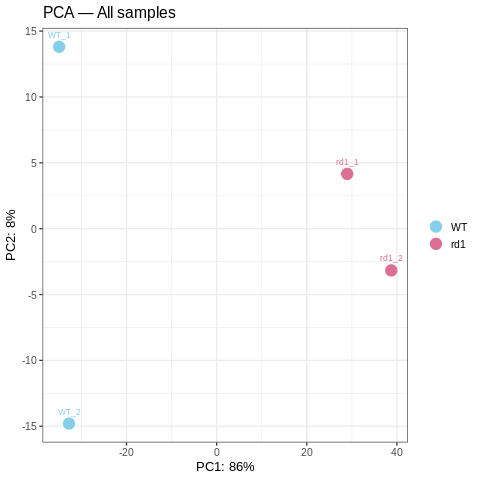

In [17]:
%%R
# ── PCA — all samples ─────────────────────────────────────────────────────────
pca_data    <- plotPCA(rld_all, intgroup = c("condition","sample_name"),ntop = nrow(counts(dds_all)), returnData = TRUE)
percent_var <- round(100 * attr(pca_data, "percentVar"))

pca_all <- ggplot(pca_data, aes(x=PC1, y=PC2, color=condition, label=sample_name)) +
  geom_point(size=5) +
  geom_text(vjust=-1.5, hjust=0.5, size=3, show.legend=FALSE) +
  scale_color_manual(values=custom_colors) +
  xlab(paste0("PC1: ",percent_var[1],"%")) +
  ylab(paste0("PC2: ",percent_var[2],"%")) +
  theme_bw(base_size=13) +
  theme(legend.title=element_blank()) +
  ggtitle("PCA — All samples")

print(pca_all)
ggsave("figures/deseq2/01_pca_all_samples.tiff", plot=pca_all, width=6, height=5, dpi=300)
cat("Saved: figures/deseq2/01_pca_all_samples.tiff\n")

Saved: figures/deseq2/02_heatmap_correlation_all.tiff


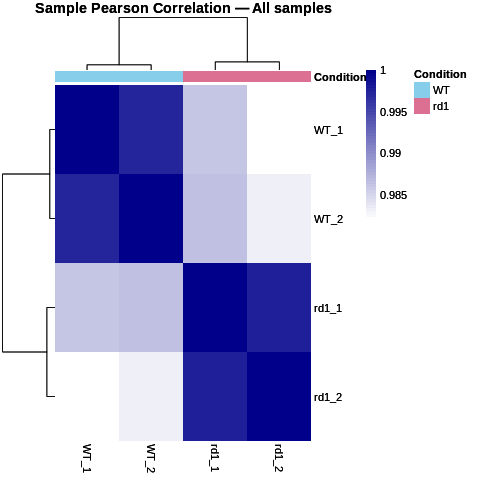

In [32]:
%%R
# ── Correlation heatmap — all samples ────────────────────────────────────────
cor_mat <- cor(as.matrix(assay(rld_all)), method = "pearson")

# Rename rows and columns from SRR IDs to readable names
colnames(cor_mat) <- col_data$sample_name
rownames(cor_mat) <- col_data$sample_name

col_annot <- data.frame(Condition = col_data$condition, row.names = col_data$sample_name)

ph1 <- pheatmap(cor_mat,
         annotation_col    = col_annot,
         annotation_colors = annot_colors,
         color  = colorRampPalette(c("white","darkblue"))(50),
         border_color = NA,
         clustering_method = "ward.D2",
         main = "Sample Pearson Correlation — All samples",
         fontsize = 11)
print(ph1)
ggsave("figures/deseq2/02_heatmap_correlation_all.tiff", plot=ph1, width=7, height=6, dpi=300)
cat("Saved: figures/deseq2/02_heatmap_correlation_all.tiff\n")

## Step 7 — Outlier removal + repeat QC

Inspect the PCA and heatmap above. If a sample clusters far from its group, add it to `samples_to_remove`.

> **Why re-run DESeq2 after removal?**  
> Size factors and dispersion estimates depend on all samples present.  
> Removing a sample changes both — the model must be **re-fitted** on the  
> clean dataset to ensure correct normalisation and p-values.

In [19]:
%%R
# ── Remove outlier(s) — update based on your PCA/heatmap ─────────────────────
# Identify SRR IDs from readable names
samples_to_remove_names <- c("")   # update based on PCA/heatmap

srr_to_remove <- rownames(col_data)[col_data$sample_name %in% samples_to_remove_names]

dds_filt <- dds_all[, !colnames(dds_all) %in% srr_to_remove]

# Re-filter genes with low counts in the reduced dataset
smallestGroupSize <- min(table(col_data$condition))
keep    <- rowSums(counts(dds_filt) >= 10) >= smallestGroupSize
dds_filt <- dds_filt[keep, ]

# Re-run DESeq2 — size factors and dispersion re-estimated on clean data
dds_filt <- DESeq(dds_filt)
rld_filt <- rlog(dds_filt, blind = FALSE)

cat("Samples remaining:", ncol(dds_filt), "\n")
cat("Genes after re-filtering:", nrow(dds_filt), "\n")
cat("\nRe-estimated size factors:\n")
print(sizeFactors(dds_filt))

Samples remaining: 4 
Genes after re-filtering: 18437 

Re-estimated size factors:
SRR15679348 SRR15679349 SRR15679346 SRR15679347 
  0.9398403   0.8648119   1.2592497   0.9992081 


using pre-existing size factors
estimating dispersions
found already estimated dispersions, replacing these
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing


Saved: figures/deseq2/03_pca_filtered.tiff


using ntop=18437 top features by variance


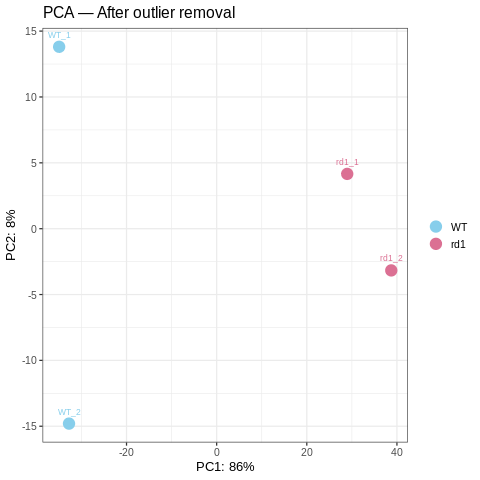

In [20]:
%%R
# ── PCA — after outlier removal ───────────────────────────────────────────────
pca_filt    <- plotPCA(rld_filt, intgroup="condition", ntop=nrow(counts(dds_filt)), returnData=TRUE)
pct_filt    <- round(100 * attr(pca_filt, "percentVar"))

pca_filt_plot <- ggplot(pca_filt, aes(x=PC1, y=PC2, color=condition, label=sample_name)) +
  geom_point(size=5) +
  geom_text(vjust=-1.5, hjust=0.5, size=3, show.legend=FALSE) +
  scale_color_manual(values=custom_colors) +
  xlab(paste0("PC1: ",pct_filt[1],"%")) +
  ylab(paste0("PC2: ",pct_filt[2],"%")) +
  theme_bw(base_size=13) +
  theme(legend.title=element_blank()) +
  ggtitle("PCA — After outlier removal")

print(pca_filt_plot)
ggsave("figures/deseq2/03_pca_filtered.tiff", plot=pca_filt_plot, width=6, height=5, dpi=300)
cat("Saved: figures/deseq2/03_pca_filtered.tiff\n")

Saved: figures/deseq2/04_heatmap_correlation_filtered.tiff


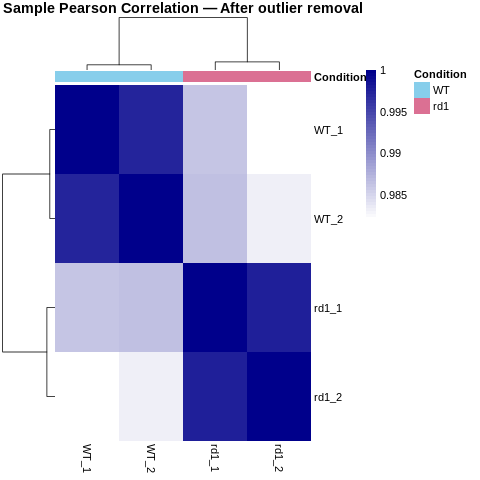

In [33]:
%%R
# ── Correlation heatmap — after outlier removal ───────────────────────────────
cor_filt <- cor(as.matrix(assay(rld_filt)), method="pearson")
colnames(cor_filt) <- col_data$sample_name
rownames(cor_filt) <- col_data$sample_name

col_annot_filt <- data.frame(Condition=col_data$condition, row.names=col_data$sample_name)

ph2 <- pheatmap(cor_filt,
         annotation_col    = col_annot_filt,
         annotation_colors = annot_colors,
         color  = colorRampPalette(c("white","darkblue"))(50),
         border_color = NA,
         clustering_method = "ward.D2",
         main = "Sample Pearson Correlation — After outlier removal",
         fontsize = 11)
ggsave("figures/deseq2/04_heatmap_correlation_filtered.tiff", plot=ph2, width=7, height=6, dpi=300)
cat("Saved: figures/deseq2/04_heatmap_correlation_filtered.tiff\n")

## Step 8 — Differential expression (DESeq2)

**Contrast:** rd1 vs WT  
**p-value correction:** Benjamini-Hochberg FDR (`padj`) — controls false discovery rate  
**Significance:** `padj < 0.05` AND `|log2FoldChange| ≥ 1` (2-fold change)

> ⚠️ Always use `padj` (adjusted), never raw `pvalue`, for significance calls and volcano plots.

In [22]:
%%R
# ── Extract DESeq2 results ────────────────────────────────────────────────────
res <- results(dds_filt,
               contrast = c("condition","rd1","WT"),
               pAdjustMethod = "BH",
               alpha = 0.05)
summary(res, alpha=0.05)

# ── Normalised counts and group means ────────────────────────────────────────
norm_counts <- counts(dds_filt, normalized=TRUE)
grp_mean    <- sapply(levels(dds_filt$condition), function(lvl)
  rowMeans(norm_counts[, dds_filt$condition == lvl, drop=FALSE]))

# ── Build full results table ──────────────────────────────────────────────────
degs_table <- as.data.frame(res)
degs_table$ENSEMBL <- rownames(degs_table)
degs_table <- cbind(degs_table, grp_mean,
                           norm_counts[rownames(degs_table), ])
degs_table$Mutation <- "RD1"

# Save full results
write.csv(degs_table, "tables/DESeq2_all_results_rd1.csv", row.names=FALSE)
cat("Total genes tested:", nrow(degs_table), "\n")
cat("Significant DEGs (padj<0.05, |LFC|>=1):",
    sum(!is.na(degs_table$padj) &
        degs_table$padj < 0.05 &
        abs(degs_table$log2FoldChange) >= 1), "\n")


out of 18437 with nonzero total read count
adjusted p-value < 0.05
LFC > 0 (up)       : 3103, 17%
LFC < 0 (down)     : 2210, 12%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 4)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results

Total genes tested: 18437 
Significant DEGs (padj<0.05, |LFC|>=1): 3017 


## Step 9 — ENSEMBL → gene symbols + Entrez IDs

In [23]:
%%R
library(org.Mm.eg.db); library(AnnotationDbi); library(clusterProfiler)

# ── Map ENSEMBL → SYMBOL + ENTREZID ──────────────────────────────────────────
gene_symbols <- mapIds(org.Mm.eg.db, keys=rownames(res), column="SYMBOL",   keytype="ENSEMBL", multiVals="first")
gene_entrez  <- mapIds(org.Mm.eg.db, keys=rownames(res), column="ENTREZID", keytype="ENSEMBL", multiVals="first")

degs_table$symbol   <- gene_symbols[rownames(res)]
degs_table$entrezid <- gene_entrez[rownames(res)]

# ── Significant DEG subsets ───────────────────────────────────────────────────
sig_genes   <- degs_table %>% filter(padj<0.05, abs(log2FoldChange)>=1, !is.na(symbol))
up_genes    <- sig_genes %>% filter(log2FoldChange > 0)
down_genes  <- sig_genes %>% filter(log2FoldChange < 0)

# ── Background: all detected genes (for correct ORA universe) ────────────────
bg_genes    <- degs_table %>% filter(!is.na(symbol)) %>% pull(symbol)

# ── Entrez ID mapping ─────────────────────────────────────────────────────────
entrez_up   <- bitr(up_genes$symbol,   fromType="SYMBOL", toType="ENTREZID", OrgDb=org.Mm.eg.db)
entrez_down <- bitr(down_genes$symbol, fromType="SYMBOL", toType="ENTREZID", OrgDb=org.Mm.eg.db)
entrez_bg   <- bitr(bg_genes,          fromType="SYMBOL", toType="ENTREZID", OrgDb=org.Mm.eg.db)

# Update and save full table with symbols
write.csv(degs_table, "tables/DESeq2_all_results_rd1.csv", row.names=FALSE)

cat("Up-regulated DEGs:", nrow(up_genes), "| mapped:", nrow(entrez_up), "\n")
cat("Down-regulated DEGs:", nrow(down_genes), "| mapped:", nrow(entrez_down), "\n")
cat("Background (all detected):", nrow(entrez_bg), "\n")

Up-regulated DEGs: 1003 | mapped: 1003 
Down-regulated DEGs: 1183 | mapped: 1183 
Background (all detected): 15354 


Loading required package: AnnotationDbi

Attaching package: ‘AnnotationDbi’

The following object is masked from ‘package:dplyr’:

    select



clusterProfiler v4.20.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan,
X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal
enrichment tool for interpreting omics data. The Innovation. 2021,
2(3):100141

Attaching package: ‘clusterProfiler’

The following object is masked from ‘package:AnnotationDbi’:

    select

The following object is masked from ‘package:IRanges’:

    slice

The following object is masked from ‘package:S4Vectors’:

    rename

The following object is masked from ‘package:stats’:

    filter

'select()' returned 1:many mapping between keys and columns
'select()' returned 1:many mapping between keys and columns
'select()' returned 1:1 mapping between keys and columns
'select()' returned 1:1 mapping between key

## Step 10 — Visualization (plotMA · EnhancedVolcano · DEG heatmap)

Saved: figures/deseq2/05_plotMA.tiff


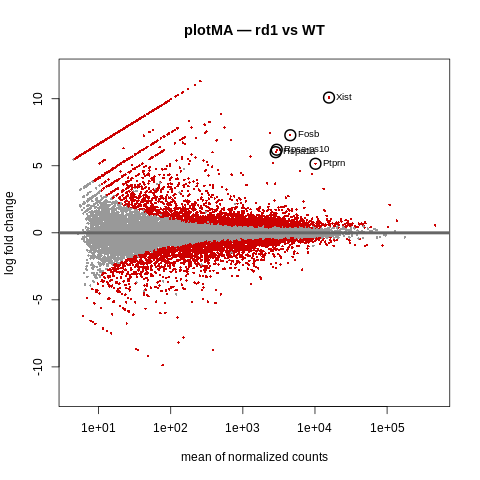

In [24]:
%%R
# ── plotMA ────────────────────────────────────────────────────────────────────
# Label top 5 most significant DEGs using gene symbols (not ENSEMBL IDs)
top5 <- degs_table %>%
  filter(!is.na(padj), !is.na(symbol)) %>%
  arrange(padj) %>% slice_head(n=5)

tiff("figures/deseq2/05_plotMA.tiff", width=6, height=5, units="in", res=300)
plotMA(res, ylim=c(-12,12), colSig="red3", alpha=0.05, main="plotMA — rd1 vs WT")
with(res[top5$ENSEMBL, ], {
  points(baseMean, log2FoldChange, col="black", cex=2, lwd=2)
  text(baseMean, log2FoldChange,
       labels = top5$symbol, pos=4, cex=0.8)
})
dev.off()
cat("Saved: figures/deseq2/05_plotMA.tiff\n")

plotMA(res, ylim=c(-12,12), colSig="red3", alpha=0.05, main="plotMA — rd1 vs WT")
with(res[top5$ENSEMBL, ], { points(baseMean, log2FoldChange, col="black", cex=2, lwd=2)
  text(baseMean, log2FoldChange, labels = top5$symbol, pos=4, cex=0.8)})

Saved: figures/deseq2/06_EnhancedVolcano.tiff


Loading required package: ggrepel
In addition: Warning messages:
1: One or more p-values is 0. Converting to 10^-1 * current lowest non-zero p-value... 
2: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
3: The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the EnhancedVolcano package.
  Please report the issue to the authors.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


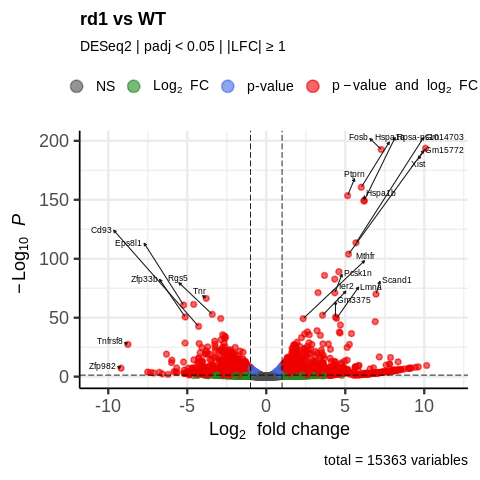

In [25]:
%%R
library(EnhancedVolcano)

# ── EnhancedVolcano ──────────────────────────────────────────────────────────
# Using padj on y-axis (NOT raw pvalue)
res_df <- as.data.frame(res)
res_df$symbol <- gene_symbols[rownames(res_df)]
res_df <- res_df[!is.na(res_df$symbol), ]

volcano <- EnhancedVolcano(res_df,
  lab            = res_df$symbol,
  x              = "log2FoldChange",
  y              = "padj",
  pCutoff        = 0.05,
  FCcutoff       = 1,
  title          = "rd1 vs WT",
  subtitle       = "DESeq2 | padj < 0.05 | |LFC| ≥ 1",
  pointSize      = 2,
  labSize        = 3,
  colAlpha       = 0.6,
  legendPosition = "top",
  drawConnectors = TRUE,
  widthConnectors = 0.5)

tiff("figures/deseq2/06_EnhancedVolcano.tiff", width=8, height=8, units="in", res=300)
print(volcano)
dev.off()
cat("Saved: figures/deseq2/06_EnhancedVolcano.tiff\n")

volcano

Saved: figures/deseq2/07_heatmap_DEGs.tiff


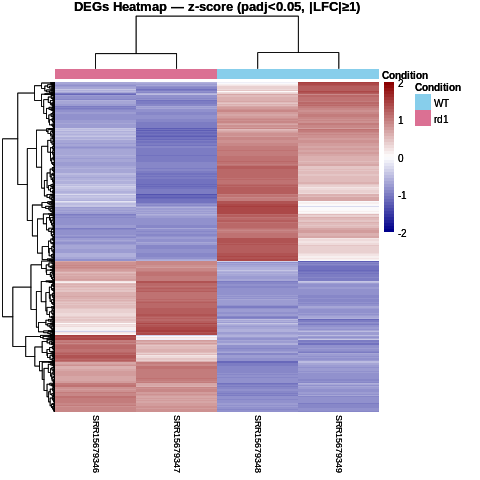

In [26]:
%%R
# ── DEG heatmap (z-score, capped ±2) ─────────────────────────────────────────
sig_norm    <- norm_counts[sig_genes$ENSEMBL, ]
rownames(sig_norm) <- sig_genes$symbol

scaled <- t(scale(t(sig_norm)))
scaled[scaled >  2] <-  2
scaled[scaled < -2] <- -2

col_annot_h <- data.frame(Condition=colData(dds_filt)$condition, row.names=colnames(dds_filt))

hm <- pheatmap(
  scaled,
  annotation_col    = col_annot_h,
  annotation_colors = annot_colors,
  cluster_rows      = TRUE,
  cluster_cols      = TRUE,
  show_rownames     = FALSE,
  show_colnames     = TRUE,
  color  = colorRampPalette(c("darkblue","white","darkred"))(50),
  breaks = seq(-2, 2, length.out=51),
  main   = "DEGs Heatmap — z-score (padj<0.05, |LFC|≥1)",
  fontsize_col = 9,
  border_color = NA
)

tiff("figures/deseq2/07_heatmap_DEGs.tiff", width=7, height=8, units="in", res=300)
print(hm)
dev.off()
cat("Saved: figures/deseq2/07_heatmap_DEGs.tiff\n")

hm

## Step 11 — Enrichment analysis (enrichGO · gost · GSEA)

In [27]:
%%R
# ── 11: GSEA ─────────────────────────────────────────────────────────────────
# Ranking metric: sign(LFC) × −log10(padj+ε)
# Uses ALL genes — no significance cutoff needed

gsea_input <- degs_table %>%
  filter(!is.na(entrezid), !is.na(padj), !is.na(log2FoldChange)) %>%
  mutate(rank_score = sign(log2FoldChange) * -log10(padj + 1e-300)) %>%
  arrange(desc(rank_score)) %>%
  distinct(entrezid, .keep_all=TRUE)

gene_list        <- gsea_input$rank_score
names(gene_list) <- gsea_input$entrezid
cat("Genes in ranked list:", length(gene_list), "\n")

gsea_go <- gseGO(geneList = gene_list,
                 OrgDb = org.Mm.eg.db,
                 keyType = "ENTREZID",
                 ont = "ALL",
                 minGSSize = 10,
                 maxGSSize = 800,
                 pvalueCutoff  = 0.05,
                 pAdjustMethod = "BH",
                 verbose = FALSE)
gsea_go <- setReadable(gsea_go, OrgDb=org.Mm.eg.db)

gsea_df <- as.data.frame(gsea_go)
gsea_df$Mutation <- "RD1"
writexl::write_xlsx(gsea_df, "tables/11_GSEA_GO_results.xlsx")
cat("Saved: tables/11_GSEA_GO_results.xlsx\n")
cat("GSEA pathways:", nrow(gsea_df), "\n")

Genes in ranked list: 15354 
Saved: tables/11_GSEA_GO_results.xlsx
GSEA pathways: 1276 


In addition: Warning messages:
1: In prepare_gsea_inputs(geneList, scoreType, exponent) :
  There are ties in the preranked stats (16.89% of the list). The order of those tied genes will be arbitrary, which may produce unexpected results.
2: In gsea(geneList = geneList, gene_sets = geneSets, minGSSize = minGSSize,  :
  There were 23 pathways for which P-values were not calculated properly due to unbalanced gene-level statistic values. For such pathways pvalue, NES and log2err are set to NA. You can try to increase nPermSimple.
3: In gsea(geneList = geneList, gene_sets = geneSets, minGSSize = minGSSize,  :
  For some pathways, in reality P-values are less than 1e-10. You can set the eps argument to zero for better estimation.
4: In calculate_qvalue(gsea_res$pvalue) :
  Invalid p-values detected (NA, non-finite, <0, or >1). qvalue will be computed on valid p-values only.
5: In enrichit::gsea_gson(geneList = geneList, exponent = exponent,  :
  NA values detected in gene set IDs. Replacing

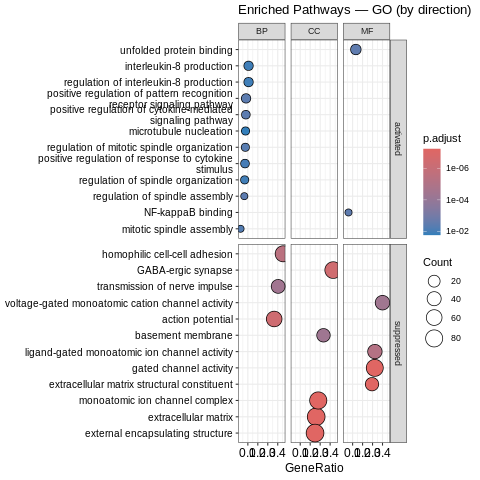

In [28]:
%%R
# --- Dotplot — faceted by direction and ontology ---
go_dot <- dotplot(
  gsea_go, showCategory = 12, split = ".sign",
  title = "Enriched Pathways — GO (by direction)", color = "p.adjust",
  font.size = 12, label_format = 50) +
  facet_grid(rows = vars(.sign), cols = vars(ONTOLOGY), scales = "free_y", drop = TRUE) +
  theme(axis.text.y = element_text(size = 10))

ggsave("figures/enrichment/11A_GSEA_GO_dotplot.tiff", plot=go_dot, width=11, height=8, dpi=300)
print(go_dot)

Picking joint bandwidth of 4.55
Picking joint bandwidth of 4.55


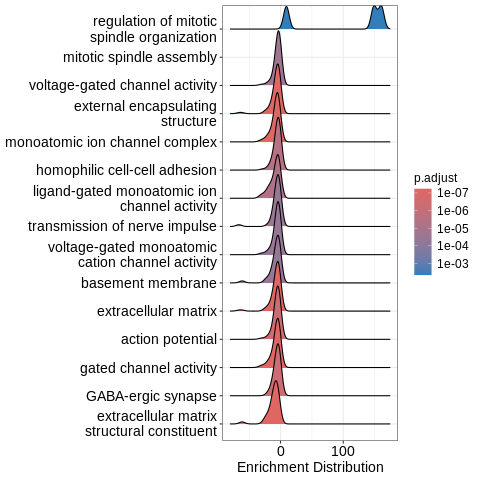

In [29]:
%%R
# --- Ridgeplot — enrichment distribution ---
go_ridge <- ridgeplot(gsea_go, showCategory = 15) +
  labs(x = "Enrichment Distribution") +
  theme(
    axis.text    = element_text(size = 12),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 12)
  )

print(go_ridge)
ggsave("figures/enrichment/11B_GSEA_GO_ridgeplot.tiff", plot=go_ridge, width=8, height=6, dpi=350)

## Step 12 — Network analysis (STRINGdb)

In [34]:
%%R
library(STRINGdb); library(igraph); library(ggraph)

string_db <- STRINGdb$new(version="11.5", species=10090, score_threshold=400, input_directory=".")

sig_string <- sig_genes %>%
  select(symbol, log2FoldChange, padj) %>%
  distinct(symbol, .keep_all=TRUE)

mapped <- string_db$map(sig_string, "symbol", removeUnmappedRows=TRUE)
cat("DEGs mapped to STRING:", nrow(mapped), "/", nrow(sig_string), "\n")

interactions <- string_db$get_interactions(mapped$STRING_id)
g <- graph_from_data_frame(interactions[, c("from","to","combined_score")], directed=FALSE)
g <- simplify(g)

V(g)$symbol <- mapped$symbol[match(V(g)$name, mapped$STRING_id)]
V(g)$degree <- degree(g)
V(g)$lfc <- mapped$log2FoldChange[match(V(g)$name, mapped$STRING_id)]

cat("Network:", vcount(g), "nodes |", ecount(g), "edges\n")

hub_df <- data.frame(
  symbol         = V(g)$symbol,
  STRING_id      = V(g)$name,
  degree         = V(g)$degree,
  log2FoldChange = V(g)$lfc
) %>% arrange(desc(degree)) %>% slice_head(n=15)
hub_df$Mutation <- "RD1"
print(hub_df)

writexl::write_xlsx(hub_df, "tables/12_hub_genes.xlsx")
cat("Saved: tables/12_hub_genes.xlsx\n")

Network: 1764 nodes | 13210 edges
   symbol                STRING_id degree log2FoldChange Mutation
1     Fn1 10090.ENSMUSP00000054499    164      -1.830312      RD1
2     Jun 10090.ENSMUSP00000102711    161       2.723168      RD1
3    Il1b 10090.ENSMUSP00000028881    129       5.871577      RD1
4   Acta2 10090.ENSMUSP00000048218    114      -3.687074      RD1
5    Igf1 10090.ENSMUSP00000056668    113      -1.888695      RD1
6   Ptk2b 10090.ENSMUSP00000106750    113       2.566352      RD1
7     Fos 10090.ENSMUSP00000021674    111       4.379408      RD1
8  Pecam1 10090.ENSMUSP00000079664    108      -2.295882      RD1
9    Rac2 10090.ENSMUSP00000036384    105       2.689730      RD1
10 Cxcl12 10090.ENSMUSP00000072800    104      -2.385481      RD1
11   Tlr4 10090.ENSMUSP00000045770     99      -3.693336      RD1
12   Cdh5 10090.ENSMUSP00000034339     97      -5.142233      RD1
13  Cxcr4 10090.ENSMUSP00000053489     96      -1.136469      RD1
14 Pik3r3 10090.ENSMUSP00000030464     95 


Attaching package: ‘igraph’

The following object is masked from ‘package:clusterProfiler’:

    simplify

The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union

The following object is masked from ‘package:GenomicRanges’:

    union

The following object is masked from ‘package:IRanges’:

    union

The following object is masked from ‘package:S4Vectors’:

    union

The following objects are masked from ‘package:BiocGenerics’:

    normalize, path, union

The following objects are masked from ‘package:generics’:

    components, union

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union

trying URL 'https://stringdb-downloads.org/download/protein.aliases.v11.5/10090.protein.aliases.v11.5.txt.gz'
Content type 'application/octet-stream' length 13598694 bytes (13.0 MB)
downloaded 13.0 MB

trying URL 'https://stringdb-downloads.org/download/protein.info.v11.5/10

Saved: figures/network/12_PPI_network.tiff


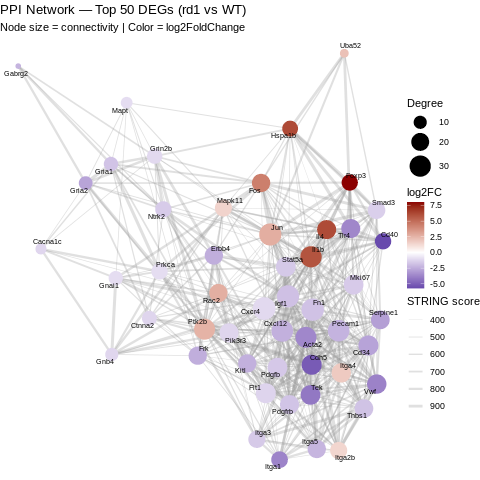

In [35]:
%%R
# ── Network plot — top 50 most connected DEGs ─────────────────────────────────
top50 <- names(sort(degree(g), decreasing=TRUE))[1:min(50,vcount(g))]

# Filter the original interactions to create the subgraph g50
# This ensures that 'combined_score' is explicitly included as an edge attribute.
filtered_interactions <- interactions %>%
  filter(from %in% top50 & to %in% top50)

g50   <- graph_from_data_frame(filtered_interactions[, c("from","to","combined_score")], directed=FALSE)

V(g50)$symbol <- V(g)$symbol[match(V(g50)$name, V(g)$name)]
V(g50)$lfc    <- V(g)$lfc[match(V(g50)$name, V(g)$name)]
V(g50)$degree <- degree(g50) # Recalculate degree for the new subgraph

net_plot <- ggraph(g50, layout="fr") +
  geom_edge_link(aes(width=combined_score), alpha=0.3, color="gray60") +
  geom_node_point(aes(size=degree, color=lfc)) +
  geom_node_text(aes(label=symbol), size=2.5, repel=TRUE) +
  scale_color_gradient2(low="darkblue", mid="white", high="darkred",
                        midpoint=0, name="log2FC") +
  scale_size(range=c(2,10), name="Degree") +
  scale_edge_width(range=c(0.2,1.5), name="STRING score") +
  theme_void(base_size=11) +
  labs(title="PPI Network — Top 50 DEGs (rd1 vs WT)",
       subtitle="Node size = connectivity | Color = log2FoldChange")

ggsave("figures/network/12A_PPI_network.tiff", plot=net_plot, width=10, height=9, dpi=300)
cat("Saved: figures/network/12_PPI_network.tiff\n")

net_plot

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Saved: figures/network/12B_GSEA_GO_cnetplot.tiff


enrichplot v1.32.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu. Gene Ontology Semantic Similarity Analysis Using
GOSemSim. In: Kidder B. (eds) Stem Cell Transcriptional Networks.
Methods in Molecular Biology. 2020, 2117:207-215. Humana, New York, NY.


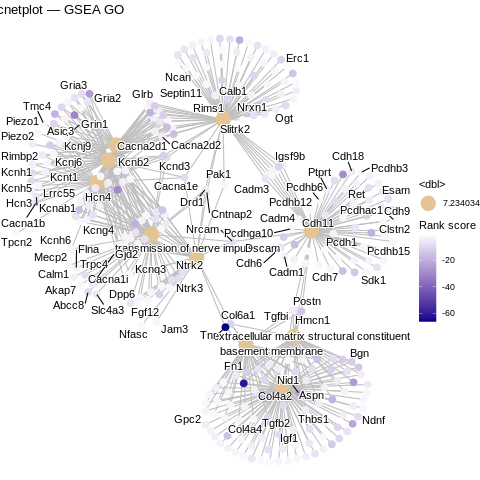

In [36]:
%%R
library(enrichplot)
# --- Network plot (cnetplot) ---
# Shows linkages between genes and enriched GO terms
# Prepare numeric vector for categorySize by taking -log10(p.adjust) of top categories
cnet_categories_p_adjust <- gsea_go@result %>%
  arrange(p.adjust) %>%
  slice_head(n = 10) %>%
  pull(p.adjust)
cnet_category_sizes <- -log10(cnet_categories_p_adjust + .Machine$double.eps)
names(cnet_category_sizes) <- (gsea_go@result %>% arrange(p.adjust) %>% slice_head(n = 10))$ID

go_cnet <- cnetplot(gsea_go,
                      showCategory  = 10,
                      categorySize  = cnet_category_sizes,
                      foldChange    = gene_list,
                      node_label    = "all") +
  scale_color_gradient2(low = "darkblue", mid = "white", high = "darkred",
                        midpoint = 0, name = "Rank score") +
  ggtitle("cnetplot — GSEA GO")

ggsave("figures/network/12B_GSEA_GO_cnetplot.tiff", plot = go_cnet, width = 12, height = 10, dpi = 400)
cat("Saved: figures/network/12B_GSEA_GO_cnetplot.tiff\n")

go_cnet

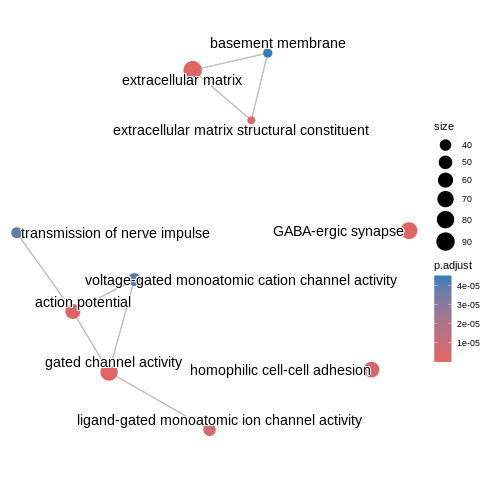

In [37]:
%%R
# --- Enrichment map ---
# Overlapping gene sets cluster together, revealing functional modules
gsea_go_sim <- pairwise_termsim(gsea_go)
go_emap <- emapplot(gsea_go_sim, showCategory = 10)
ggsave("figures/network/12C_GSEA_GO_emapplot.tiff", plot = go_emap, width = 10, height = 7, dpi = 400, compression = "lzw")
go_emap

## Pipeline complete!

| Step | Tool | Key output |
|------|------|-----------|
| Download | sra-tools | `data/fastq/*.fastq.gz` |
| QC | FastQC + MultiQC | `figures/qc/multiqc_*.html` |
| Trimming | **fastp** | `data/trimmed/` + per-sample HTML |
| Alignment | **HISAT2** | `data/bam/*_sorted.bam` |
| Quantification | **featureCounts** | `data/counts/gene_counts_clean.csv` |
| DESeq2 QC | rlog + PCA + heatmap | `figures/deseq2/01–04_*.tiff` |
| DEGs | DESeq2 (BH/FDR) | `tables/DESeq2_all_results_rd1.csv` |
| Visualization | plotMA + Volcano + heatmap | `figures/deseq2/05–07_*.tiff` |
| GSEA | gseGO (all genes ranked) | `tables/11C_GSEA_GO_results.xlsx` |
| Network | STRINGdb + igraph/ centplot | `tables/12_hub_genes.xlsx` |

---

### 📁 Output structure
```
figures/
├── qc/           FastQC, MultiQC, fastp, HISAT2 alignment summaries
├── deseq2/       PCA, heatmaps, plotMA, volcano, DEG heatmap
├── enrichment/   GSEA dotplots
└── network/      PPI network, cnetplot, emapplot
tables/
├── DESeq2_all_results_rd1.csv
├── 11_GSEA_GO_results.xlsx
└── 12_hub_genes.xlsx
```

### 🔗 References
| Tool | Citation |
|------|---------|
| fastp | [Chen et al., 2018](https://doi.org/10.1093/bioinformatics/bty560) |
| HISAT2 | [Kim et al., 2019](https://doi.org/10.1038/s41587-019-0201-4) |
| featureCounts | [Liao et al., 2014](https://doi.org/10.1093/bioinformatics/btt656) |
| DESeq2 | [Love et al., 2014](https://doi.org/10.1186/s13059-014-0550-8) |
| clusterProfiler | [Wu et al., 2021](https://doi.org/10.1016/j.xinn.2021.100141) |
| gprofiler2 | [Kolberg et al., 2021](https://doi.org/10.1093/nar/gkab301) |
| EnhancedVolcano | [Blighe et al.](https://github.com/kevinblighe/EnhancedVolcano) |
| STRINGdb | [Szklarczyk et al., 2021](https://doi.org/10.1093/nar/gkaa1074) |